## Citywide Trend Analysis (2016-2025)

This notebook builds a citywide analytical baseline for Get It Done closed requests.

### Objectives
- Consolidate annual closed-case datasets into one analysis table
- Clean and standardize core request, location, and timing fields
- Profile service-level response-time patterns across the full period
- Quantify first-order associations with `case_age_days`

### Output
A cleaned, feature-ready dataset and citywide descriptive findings used by downstream district and modeling notebooks.


In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, datetime as dt, numpy as np, glob, os
import sys

pd.set_option('display.max_columns', None)

DRIVE_URL = "https://drive.google.com/uc?export=download&id=1F06NYKBF8loCTPEaPT_qIhcQy2T5iM6H"
DATA_PATH = "data.csv"

# Preferred: local multi-file raw data. Fallback: single downloaded CSV.
all_files = sorted(glob.glob("csv_files/get_it_done_requests_closed_20*_datasd.csv"))

if all_files:
    print(f"Loading {len(all_files)} local annual CSV files from csv_files/...")
    df_list = []
    for file in all_files:
        year = file.split('_')[-2]
        df = pd.read_csv(file)
        if 'year' not in df.columns:
            df['year'] = year
        df_list.append(df)
        print(f"Loaded {year}: {len(df)} rows")
    all_data = pd.concat(df_list, ignore_index=True)
else:
    if not os.path.exists(DATA_PATH):
        print("No local annual CSV files found. Attempting Google Drive download...")
        try:
            import gdown
            gdown.download(DRIVE_URL, DATA_PATH, quiet=False)
        except Exception as e:
            raise RuntimeError(
                "Could not load local CSVs and automatic download failed. "
                "Install gdown (`pip install gdown`) or place data.csv in project root."
            ) from e

    all_data = pd.read_csv(DATA_PATH, low_memory=False)
    if 'year' not in all_data.columns and 'date_requested' in all_data.columns:
        all_data['date_requested'] = pd.to_datetime(all_data['date_requested'], errors='coerce')
        all_data['year'] = all_data['date_requested'].dt.year
    print(f"Loaded single-file dataset: {len(all_data):,} rows")



/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_81709/4142420069.py:11: DtypeWarning: Columns (7,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2016: 33631 rows
Loaded 2017: 139500 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_81709/4142420069.py:11: DtypeWarning: Columns (2,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2018: 169603 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_81709/4142420069.py:11: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2019: 302699 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_81709/4142420069.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2020: 280071 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_81709/4142420069.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2021: 359879 rows
Loaded 2022: 349241 rows
Loaded 2023: 432431 rows
Loaded 2024: 429933 rows
Loaded 2025: 378618 rows


## Data Cleaning

This section prepares a consistent analysis dataset.

### Steps
- Load annual CSV files and append a year field
- Remove invalid/duplicate records where needed
- Standardize key categorical labels (service and neighborhood naming)
- Validate missingness and data types for modeling-critical fields

### Notes
Data quality issues are expected in multi-year operational datasets. Cleaning decisions here prioritize consistency and reproducibility.


In [2]:
master = all_data[all_data["status"] != "Referred"].drop(columns=["referred"])
# Clean neighborhood names
master["comm_plan_name"] = master["comm_plan_name"].str.title()
def clean_case_type(case):
    if not isinstance(case,str):
        return case
    
    if "graffiti" in case.lower():
        return "Graffiti"
    return case

#Drop rows where service_name == "Other"(vague)
before_rows = len(master)
master = master[master["service_name"] != "Other"]
print(f"✓ Dropped 'Other' service type: {before_rows - len(master):,} rows")
#Remove invalid case_age_days (negative values)
before_rows = len(master)
master = master[master["case_age_days"] >= 0]
print(f"✓ Dropped negative response times: {before_rows - len(master):,} rows")
#Remove duplicates
before_rows = len(master)
master = master[~master['service_request_id'].duplicated()]
print(f"✓ Dropped duplicate IDs: {before_rows - len(master):,} rows")

#Clean service_name values
master["service_name"] = master["service_name"].apply(clean_case_type)

#Drop rows with NA in service_name
before_rows = len(master)
master = master.dropna(subset=["service_name"])
after_rows = len(master)

print(
    
    f"Dropped {before_rows - after_rows} rows due to NA values"
)
#Handling Missing Features for Modeling


# Fill missing comm_plan_name with 'Unknown'
missing_neighborhood = master['comm_plan_name'].isna().sum()
master['comm_plan_name'] = master['comm_plan_name'].fillna('Unknown')
print(f"✓ Filled {missing_neighborhood:,} missing neighborhoods with 'Unknown'")

# Fill missing case_origin with 'Unknown'
missing_origin = master['case_origin'].isna().sum()
master['case_origin'] = master['case_origin'].fillna('Unknown')
print(f"✓ Filled {missing_origin:,} missing case_origins with 'Unknown'")



✓ Dropped 'Other' service type: 26,693 rows
✓ Dropped negative response times: 670 rows
✓ Dropped duplicate IDs: 17 rows
Dropped 692 rows due to NA values
✓ Filled 32,519 missing neighborhoods with 'Unknown'
✓ Filled 479 missing case_origins with 'Unknown'


## Feature Engineering

This section creates modeling and diagnostics features from request metadata.

### Added Features
- Temporal fields (year, month, day of week, hour)
- Request text proxies (for example, description length)
- Service- and geography-level frequency/count attributes

### Purpose
These features support both exploratory analysis and predictive modeling in later notebooks.


In [3]:
# Adding Features for modeling

model_data = master.copy()
#handles outliers
model_data = model_data[model_data["case_age_days"]<= 365*2]
# Continue with model_data (already filtered for outliers)
# Continue with model_data (already filtered for outliers)
print("\n=== FEATURE ENGINEERING ON MODEL_DATA ===")
print(f"Starting with {len(model_data):,} rows (after outlier removal)")

# Parse dates
model_data['date_requested'] = pd.to_datetime(model_data['date_requested'], errors='coerce')

# Temporal features
model_data['year'] = model_data['date_requested'].dt.year
model_data['month'] = model_data['date_requested'].dt.month
model_data['day_of_week'] = model_data['date_requested'].dt.dayofweek
model_data['hour'] = model_data['date_requested'].dt.hour
model_data['quarter'] = model_data['date_requested'].dt.quarter
model_data['is_weekend'] = (model_data['day_of_week'] >= 5).astype(int)

# Location features
model_data['is_district_56'] = model_data['council_district'].isin([5, 6]).astype(int)

# Fill missing council_district with 0 (Unknown)
missing_district = model_data['council_district'].isna().sum()
model_data['council_district'] = model_data['council_district'].fillna(0)
print(f"✓ Filled {missing_district:,} missing council_districts with 0 (Unknown)")

# Request type features
infrastructure_types = [
    'Pothole',
    'Street Light Maintenance',
    'Traffic Signal Issue',
    'Traffic Signal Timing',
    'Traffic Sign Maintenance',
    'Sidewalk Repair Issue',
    'Pavement Maintenance',
    'Street Repair',
    'Curb Repair'
]
model_data['is_infrastructure'] = model_data['service_name'].isin(infrastructure_types).astype(int)
model_data['is_followup'] = model_data['service_request_parent_id'].notna().astype(int)

# Text features
model_data['description_length'] = model_data['public_description'].str.len().fillna(0)
model_data['has_description'] = (model_data['description_length'] > 0).astype(int)

# Target variable for classification
model_data['response_category'] = pd.cut(
    model_data['case_age_days'],
    bins=[0, 3, 7, 21, 90,730],
    labels=['very_fast', 'fast', 'medium', 'slow',"super_slow"],
    include_lowest=True
)

print("✓ Created all features")
# Dropping columns
columns_to_drop = [
    'date_closed',  # Already have case_age_days
    'service_request_id',  # Just an ID
    'service_request_parent_id',  # Used for is_followup feature
    'public_description',  # Used for description_length
    'sap_notification_number',  # Internal ID
    'specify_the_issue',  # Too many missing
    'public_url',  # Not useful for prediction
    'iamfloc',  # Internal code
    'floc',  # Internal code
    'park_name',  # Too many missing
    'service_name_detail',  # Redundant with service_name
    
]
model_data = model_data.drop(columns=columns_to_drop)
print(f"✓ Dropped {len(columns_to_drop)} unnecessary columns")

# Summary
print("\n=== MODEL DATA SUMMARY ===")
print(f"Total rows: {len(model_data):,}")
print(f"Total columns: {len(model_data.columns)}")

print(f"\nTarget variable (case_age_days) statistics:")
print(model_data['case_age_days'].describe())

print(f"\nResponse category distribution:")
print(model_data['response_category'].value_counts())

print(f"\nKey features created:")
print(f"  - Temporal: year, month, day_of_week, hour, quarter, is_weekend")
print(f"  - Location: is_district_56, council_district (0 = Unknown)")
print(f"  - Request type: is_infrastructure, is_followup")
print(f"  - Text: description_length, has_description")
print(f"  - Target: response_category (very_fast/fast/medium/slow)")

# Check for any remaining missing values in key columns
print("\n=== MISSING VALUES CHECK ===")
key_cols = ['service_name', 'council_district', 'case_age_days', 'year', 'month', 'day_of_week']
missing_summary = model_data[key_cols].isna().sum()
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values in key columns ✓")

print(f"\n✓ 'model_data' ready with {len(model_data):,} rows and {len(model_data.columns)} columns")
print(f"✓ Original 'master' dataframe preserved for EDA")



=== FEATURE ENGINEERING ON MODEL_DATA ===
Starting with 2,452,953 rows (after outlier removal)
✓ Filled 32,059 missing council_districts with 0 (Unknown)
✓ Created all features
✓ Dropped 11 unnecessary columns

=== MODEL DATA SUMMARY ===
Total rows: 2,452,953
Total columns: 25

Target variable (case_age_days) statistics:
count    2.452953e+06
mean     3.293461e+01
std      8.359300e+01
min      0.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      2.200000e+01
max      7.300000e+02
Name: case_age_days, dtype: float64

Response category distribution:
response_category
very_fast     1067713
medium         423587
slow           399553
fast           339958
super_slow     222142
Name: count, dtype: int64

Key features created:
  - Temporal: year, month, day_of_week, hour, quarter, is_weekend
  - Location: is_district_56, council_district (0 = Unknown)
  - Request type: is_infrastructure, is_followup
  - Text: description_length, has_description
  - Target: response_category (v

## Aggregations by District and Neighborhood

This section calculates response-time summaries and request counts by geography.

### Why This Matters
- Establishes baseline geographic variation
- Highlights high-volume and high-latency areas
- Provides context for district-level fairness and service-mix analysis


In [4]:
#calculate counts and merge
service_name_count = (master.value_counts(subset=["service_name"])
                      .rename_axis("service_name")
                      .reset_index(name="case_type_count"))
neighborhood_count = (master.value_counts("comm_plan_name")).reset_index(name = "neighborhood_count")
district_count = (master.value_counts("council_district")).reset_index(name = "district_count")

# Merge counts into master
master = master.merge(
    neighborhood_count, on="comm_plan_name", how="left")
master = master.merge(service_name_count, on="service_name", how="left")
master = master.merge(district_count, on = "council_district", how = "left")

#filter by case_type_count
closed_average_case = (master[master["case_type_count"] > 100]
                       [["case_age_days", "service_name"]]
                       .groupby("service_name")
                       .median()
                       .sort_values(by="case_age_days", ascending=False)
                       )

district_case_average = master.groupby("council_district")["case_age_days"].agg(
    [
        "mean",
        "median",
        "count"
    ]
)
neighberhood_case_average = master.groupby("comm_plan_name")["case_age_days"].agg(
    [
        "mean",
        "median",
        "count"
    ]
)

## Service Mix and Slowest Services

This section compares service volume and service latency.

### Deliverables
- Top service types by request volume
- Slowest service types by median `case_age_days` (with minimum-count filters)

### Interpretation
High-volume services are not always the slowest. Service composition is an important driver of observed wait times.


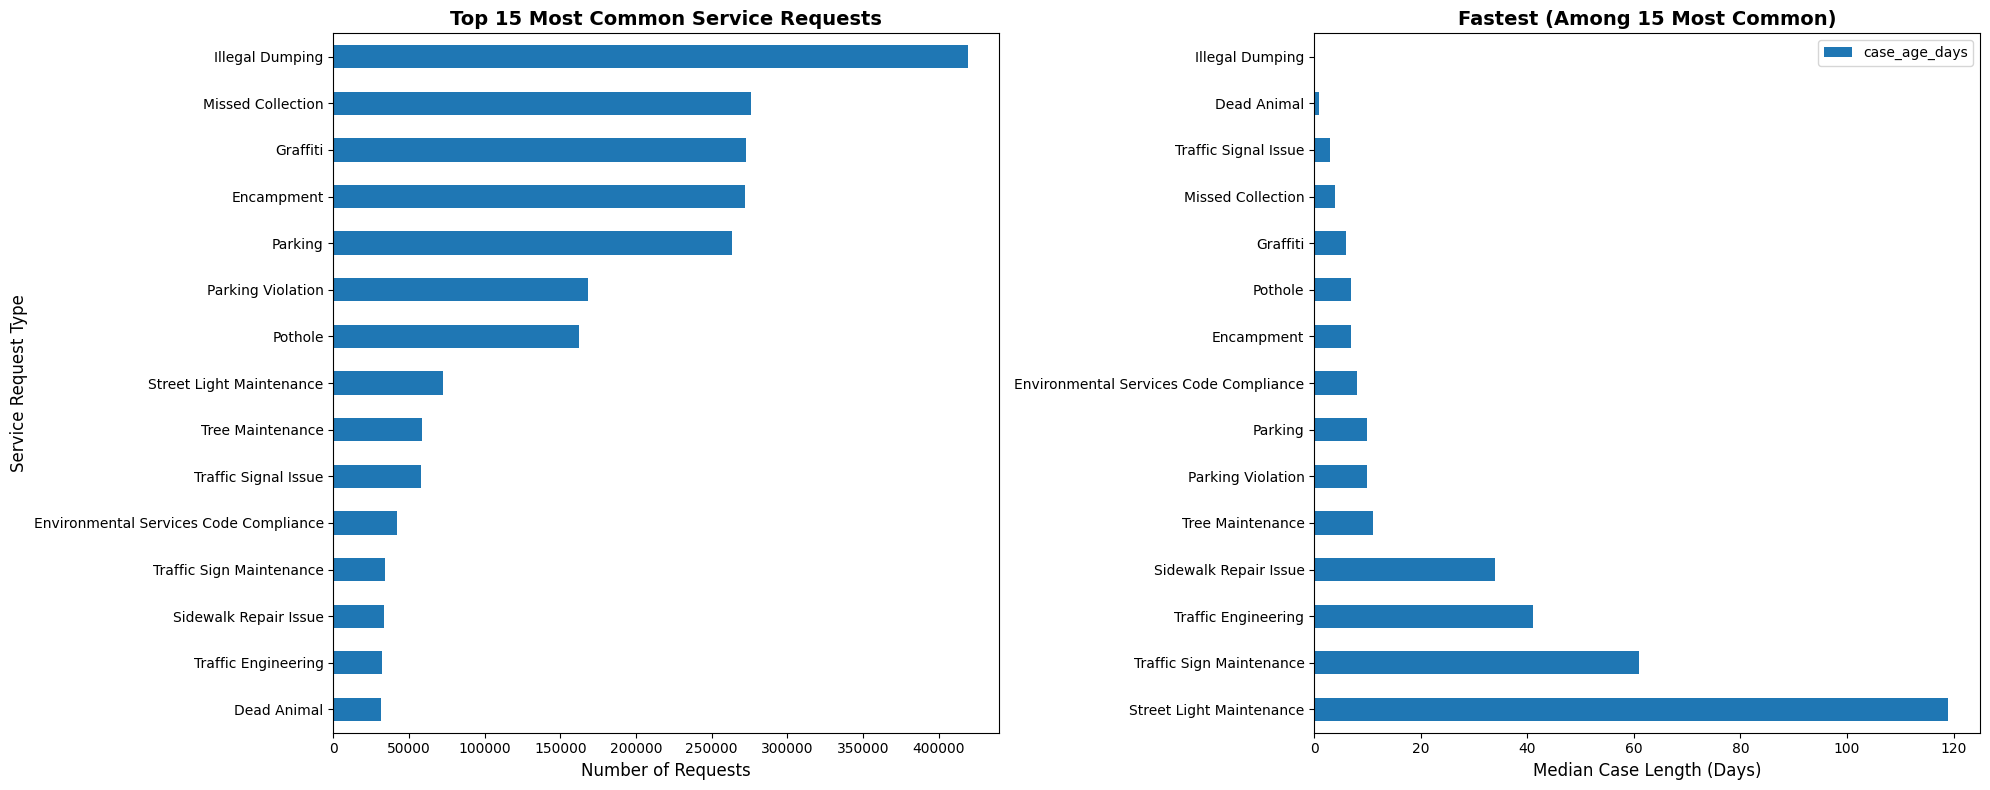

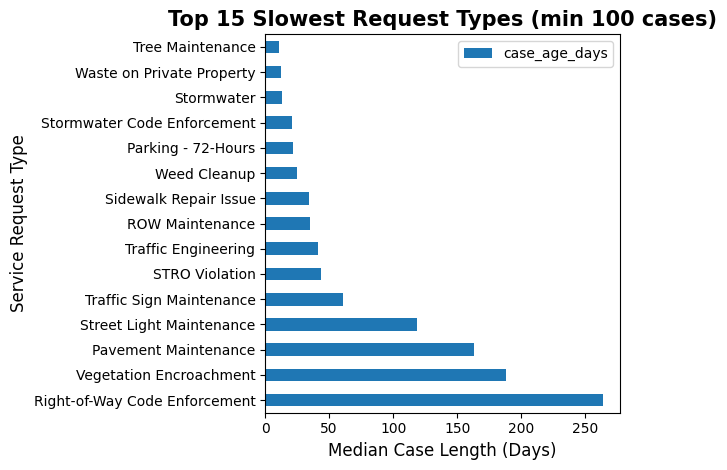


Total requests loaded: 2,475,999
Years: ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [5]:
top_15_requests = service_name_count.head(15).sort_values("case_type_count", ascending=True)
most_common_request_lists = list(top_15_requests["service_name"])
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
# --- Plot 1: Top 15 most common ---
top_15_requests.set_index("service_name")["case_type_count"].plot(
    kind="barh",
    ax=axes[0]
)
axes[0].set_xlabel("Number of Requests", fontsize=12)
axes[0].set_ylabel("Service Request Type", fontsize=12)
axes[0].set_title("Top 15 Most Common Service Requests", fontsize=14, fontweight="bold")

# --- Plot 2: Fastest among most common ---
closed_average_case[
    closed_average_case.index.isin(most_common_request_lists)
].sort_values("case_age_days", ascending=False).head(15).plot(
    kind="barh",
    ax=axes[1]
)
axes[1].set_xlabel("Median Case Length (Days)", fontsize=12)
axes[1].set_ylabel("")
axes[1].set_title("Fastest (Among 15 Most Common)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# Plot slowest
closed_average_case.head(15).plot(kind="barh")
plt.xlabel('Median Case Length (Days)', fontsize=12)
plt.ylabel('Service Request Type', fontsize=12)
plt.title('Top 15 Slowest Request Types (min 100 cases)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal requests loaded: {len(master):,}")
print(f"Years: {sorted(master['year'].unique())}")



=== RESPONSE TIME DISTRIBUTION ===
count    2.475999e+06
mean     4.380672e+01
std      1.469359e+02
min      0.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      2.300000e+01
max      3.478000e+03
Name: case_age_days, dtype: float64


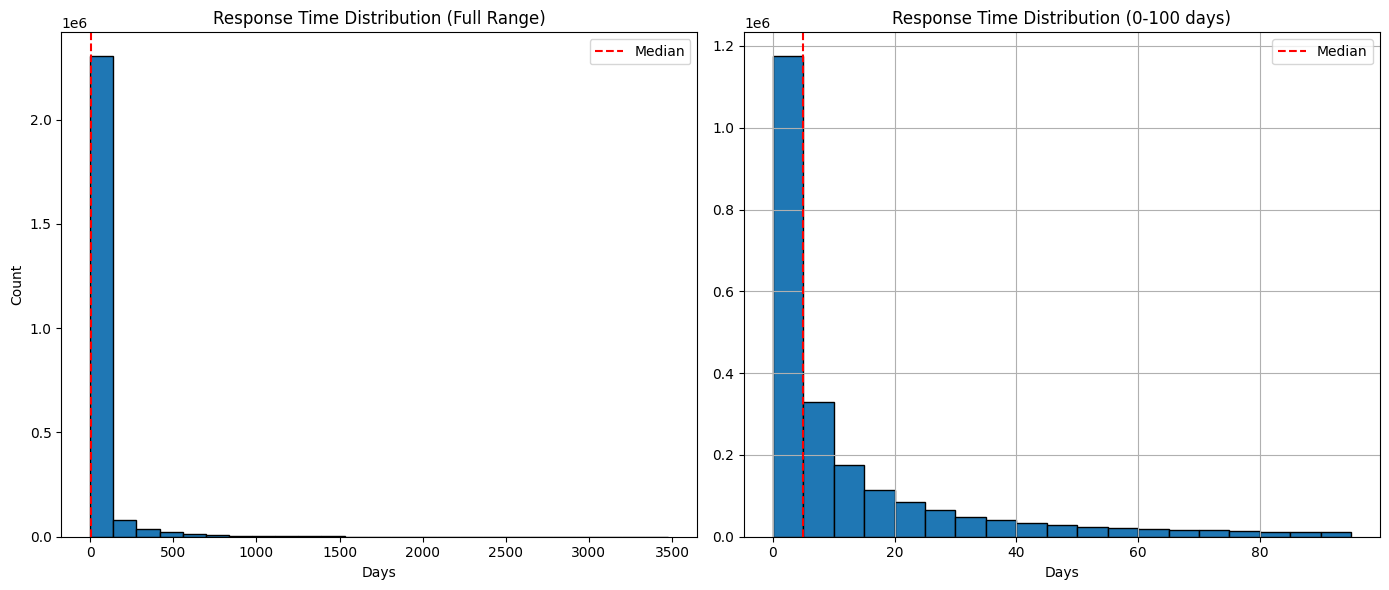

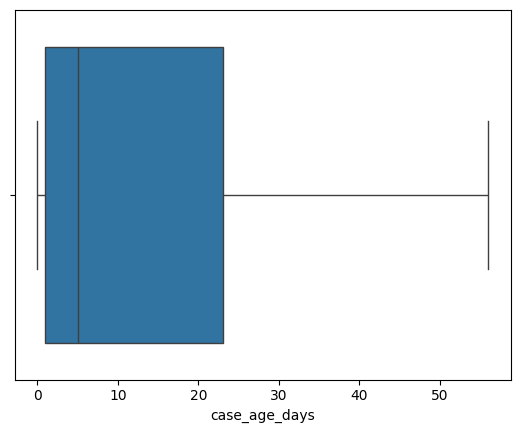


Cases > 365 days: 68,672 (2.8%)
Max: 3478 days


In [6]:
# Understand what you're predicting
print("=== RESPONSE TIME DISTRIBUTION ===")
print(master['case_age_days'].describe())

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Full distribution
ax1.hist(master['case_age_days'], bins=25, edgecolor='black')
ax1.set_xlabel('Days')
ax1.set_ylabel('Count')
ax1.set_title('Response Time Distribution (Full Range)')
ax1.axvline(master['case_age_days'].median(), color='red', linestyle='--', label='Median')
ax1.legend()

# Capped at reasonable max
master[master['case_age_days'] <= 100]['case_age_days'].hist(bins=np.arange(0,100,5), ax=ax2, edgecolor='black')
ax2.set_xlabel('Days')
ax2.set_title('Response Time Distribution (0-100 days)')
ax2.axvline(master['case_age_days'].median(), color='red', linestyle='--', label='Median')
ax2.legend()

plt.tight_layout()
plt.show()

sns.boxplot(x=master["case_age_days"],data=master,showfliers = False)
plt.show()
# Check for extreme outliers
print(f"\nCases > 365 days: {(master['case_age_days'] > 365).sum():,} ({(master['case_age_days'] > 365).sum()/len(master)*100:.1f}%)")
print(f"Max: {master['case_age_days'].max():.0f} days")

# Should I cap outliers for modeling

## Correlation Findings for Response Time

### Summary
- Infrastructure-related requests show the strongest positive association with longer waits (weak to moderate effect).
- More recent years are associated with lower wait times, consistent with system-level improvement over time.
- Calendar features (month/day/weekend) show limited standalone linear association in this dataset.

### Caution
For categorical variables, these relationships should be interpreted as association patterns rather than causal effects.


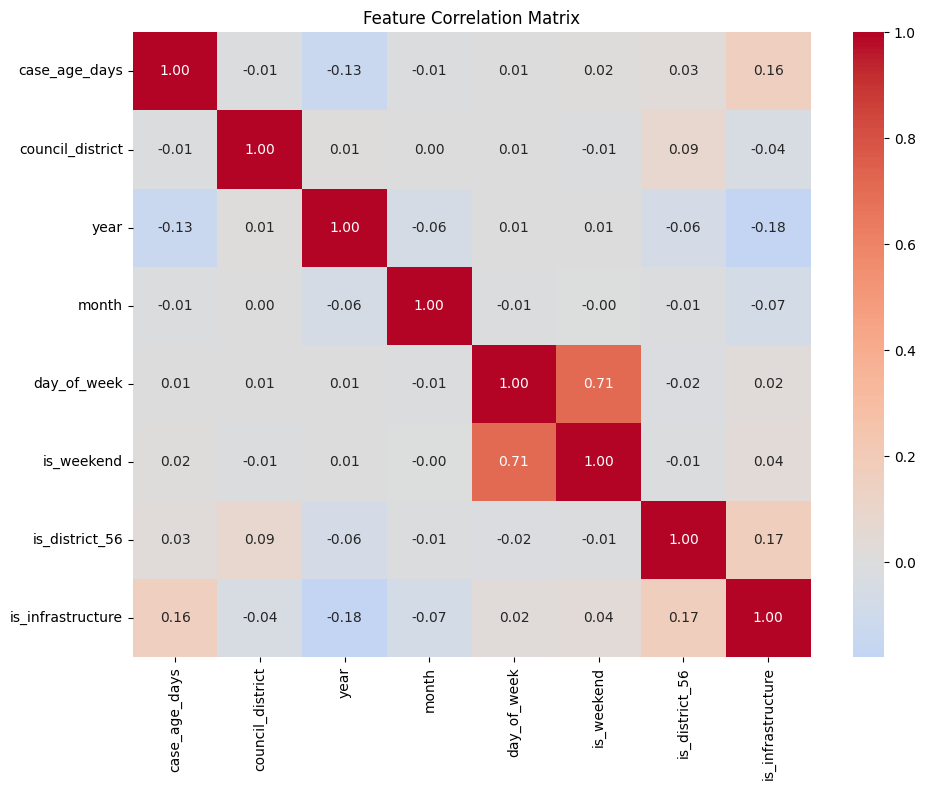


=== CORRELATION WITH RESPONSE TIME ===
case_age_days        1.000000
is_infrastructure    0.162158
is_district_56       0.027588
is_weekend           0.015782
day_of_week          0.009431
month               -0.009371
council_district    -0.010143
year                -0.132170
Name: case_age_days, dtype: float64


In [7]:
# Create potential features first

# Correlation matrix for numerical features
numerical_features = ['case_age_days', 'council_district', 'year', 'month', 
                      'day_of_week', 'is_weekend', 'is_district_56', 'is_infrastructure']

corr_data = model_data[numerical_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlations with target
print("\n=== CORRELATION WITH RESPONSE TIME ===")
print(corr_data['case_age_days'].sort_values(ascending=False))

=== MONTHLY PATTERNS ===
month
1     7.0
2     6.0
3     5.0
4     4.0
5     5.0
6     5.0
7     5.0
8     5.0
9     5.0
10    5.0
11    5.0
12    5.0
Name: case_age_days, dtype: float64


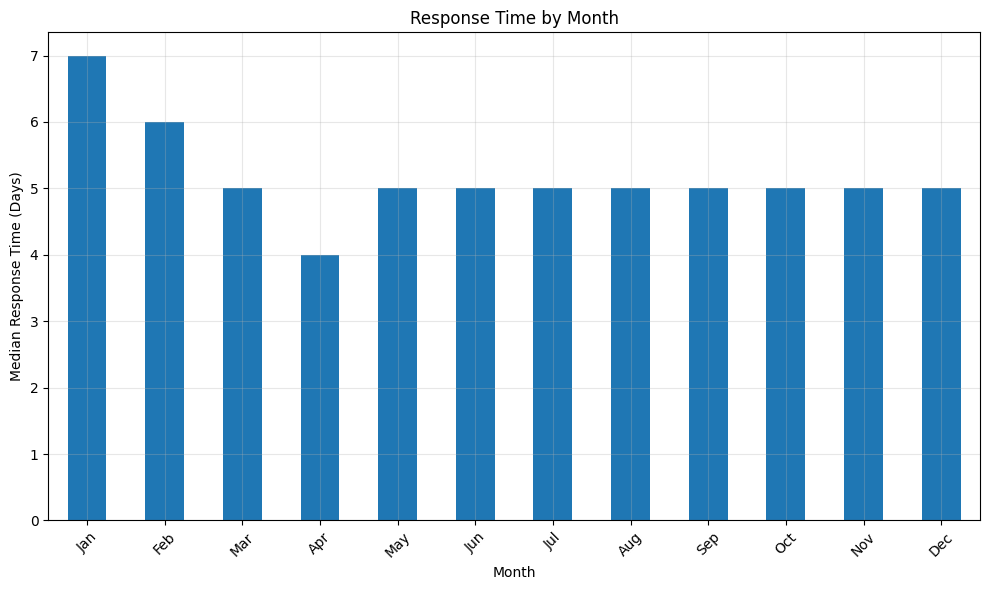


=== DAY OF WEEK PATTERNS ===
day_of_week
0    3.0
1    6.0
2    5.0
3    5.0
4    5.0
5    6.0
6    7.0
Name: case_age_days, dtype: float64


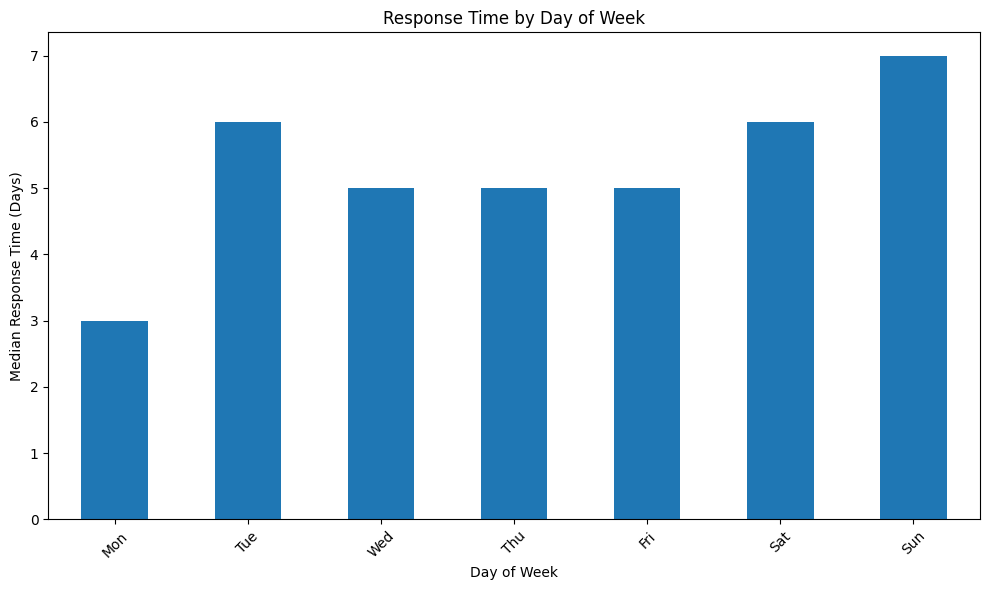


=== YEARLY TRENDS ===
year
2016    20.0
2017    19.0
2018    10.0
2019     5.0
2020     5.0
2021     8.0
2022     7.0
2023     4.0
2024     3.0
2025     2.0
Name: case_age_days, dtype: float64


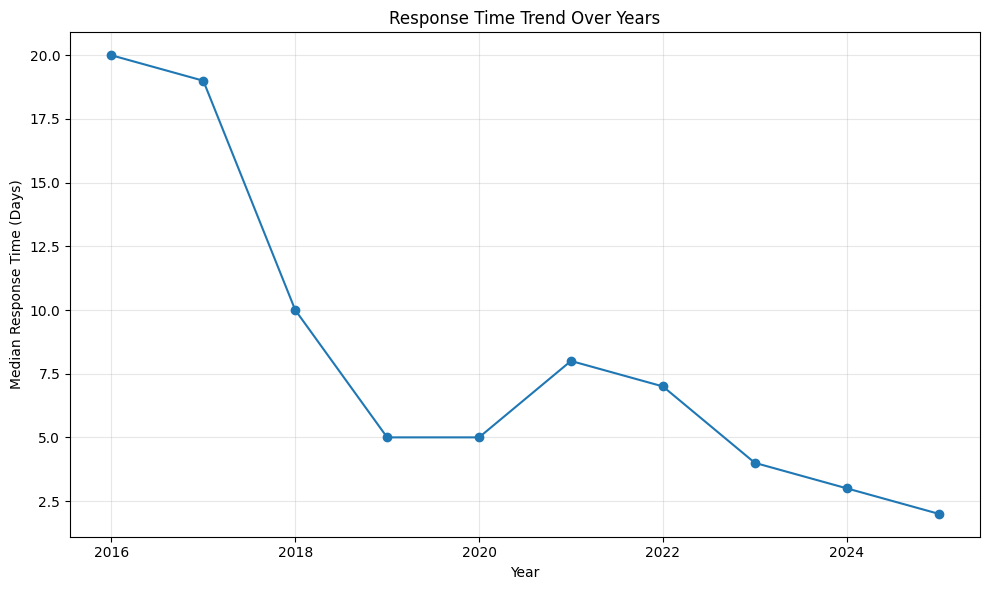

In [8]:
# Month patterns
print("=== MONTHLY PATTERNS ===")
monthly = model_data.groupby('month')['case_age_days'].median()
print(monthly)

plt.figure(figsize=(10, 6))
monthly.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Median Response Time (Days)')
plt.title('Response Time by Month')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Day of week
print("\n=== DAY OF WEEK PATTERNS ===")
dow = model_data.groupby('day_of_week')['case_age_days'].median()
print(dow)

plt.figure(figsize=(10, 6))
dow.plot(kind='bar')
plt.xlabel('Day of Week')
plt.ylabel('Median Response Time (Days)')
plt.title('Response Time by Day of Week')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
plt.tight_layout()
plt.show()

# Year trends
print("\n=== YEARLY TRENDS ===")
yearly = model_data.groupby('year')['case_age_days'].median()
print(yearly)

plt.figure(figsize=(10, 6))
yearly.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Median Response Time (Days)')
plt.title('Response Time Trend Over Years')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Check missing values
print("=== MISSING DATA ===")
missing = master.isnull().sum()
missing_pct = (missing / len(master) * 100)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_pct
}).sort_values('Percent', ascending=False)

print(missing_df[missing_df['Percent'] > 0])

# Check data quality issues
print("\n=== DATA QUALITY CHECKS ===")
print(f"Zero response times: {(master['case_age_days'] == 0).sum()}")
print(f"Very long times (>2 years): {(master['case_age_days'] > 730).sum()}")

# Check for duplicates
print(f"\nDuplicate service_request_ids: {master['service_request_id'].duplicated().sum()}")

=== MISSING DATA ===
                           Missing    Percent
specify_the_issue          2424673  97.927059
park_name                  2393027  96.648949
service_request_parent_id  2130929  86.063403
sap_notification_number    2017978  81.501568
public_url                 1934839  78.143771
iamfloc                     970630  39.201551
service_name_detail         853641  34.476629
floc                        844027  34.088342
zipcode                     587933  23.745284
public_description          322341  13.018624
comm_plan_code               32519   1.313369
council_district             32253   1.302626
district_count               32253   1.302626
lng                          26818   1.083118
lat                          26818   1.083118
street_address                7072   0.285622

=== DATA QUALITY CHECKS ===
Zero response times: 538188
Very long times (>2 years): 23046

Duplicate service_request_ids: 0


## Notebook Summary

This notebook establishes the citywide baseline dataset and identifies broad response-time patterns.
It is the preprocessing and context foundation for district-level and predictive modeling notebooks.
